In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os.path as path
import seaborn as sns

## 1.Melihat Karakteristik Dataset

In [83]:
df = pd.read_csv('../0.dataset/House Price Prediction Dataset.csv')
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [84]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.shape

(2000, 10)

In [87]:
df = df.drop(columns='Id' , errors='ignore')
df.shape

(2000, 9)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [89]:
feature_numerik = ['Area','Bedrooms','Bathrooms','Floors']
feauture_categori = ['Location','Condition','Garage']
feauture_time = ['YearBuilt']
feauture_target = 'Price'

In [90]:
df[feature_numerik].describe()

,Area,Bedrooms,Bathrooms,Floors
count,2000.000000,2000.000000,2000.00000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500
std,1295.146799,1.424606,1.10899,0.809188
min,501.000000,1.000000,1.00000,1.000000
25%,1653.000000,2.000000,2.00000,1.000000
50%,2833.000000,3.000000,3.00000,2.000000
75%,3887.500000,4.000000,4.00000,3.000000
max,4999.000000,5.000000,4.00000,3.000000


## 2.Analisis Univariat

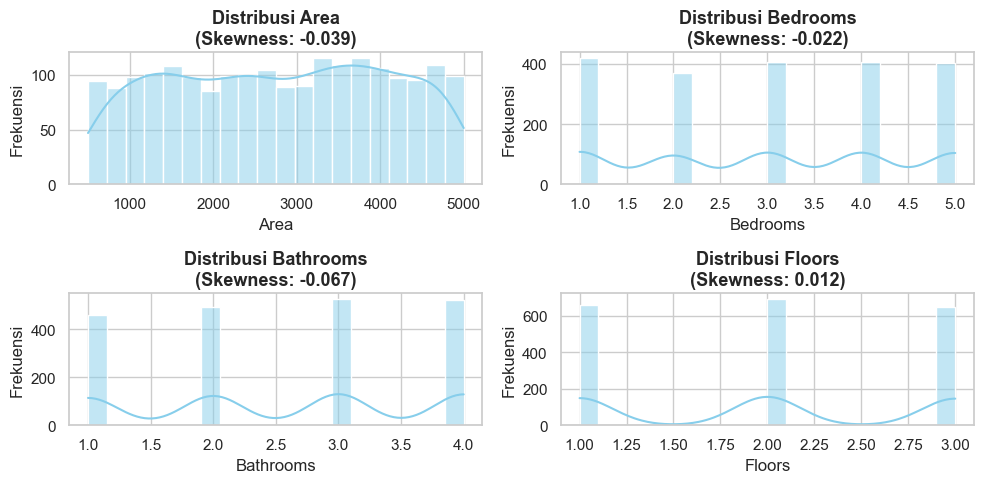

In [115]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(2,2,figsize=(10,5))
axes = axes.flatten()

for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='skyblue',bins=20)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13,fontweight="bold")
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
plt.tight_layout()
plt.show()

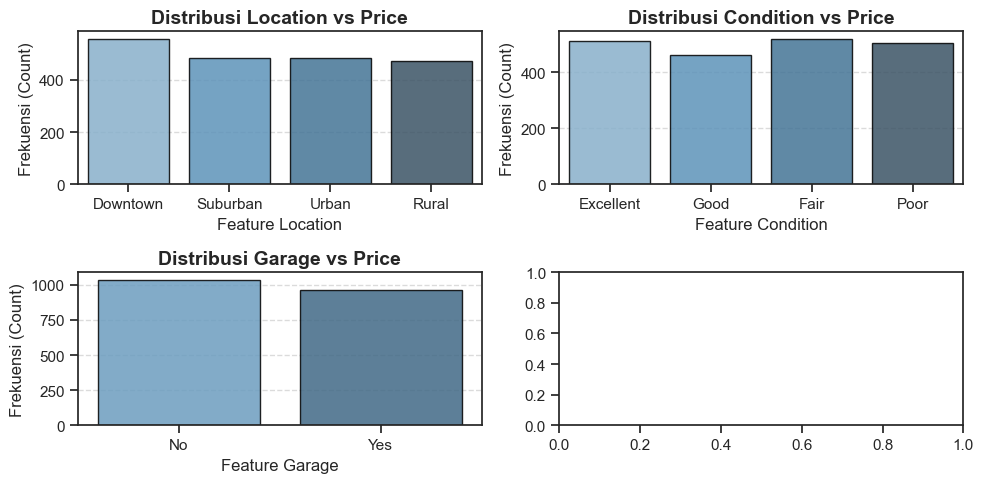

In [116]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.flatten()

for i, feature in enumerate(feauture_categori):
    sns.countplot(data=df,x=feature,hue=feature,ax= axes[i],palette='Blues_d',edgecolor="black",alpha=0.85,)
    axes[i].set_title(f"Distribusi {feature} vs {feauture_target}",fontsize=14,fontweight="bold",)
    axes[i].set_xlabel(f"Feature {feature}", fontsize=12)
    axes[i].set_ylabel("Frekuensi (Count)", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

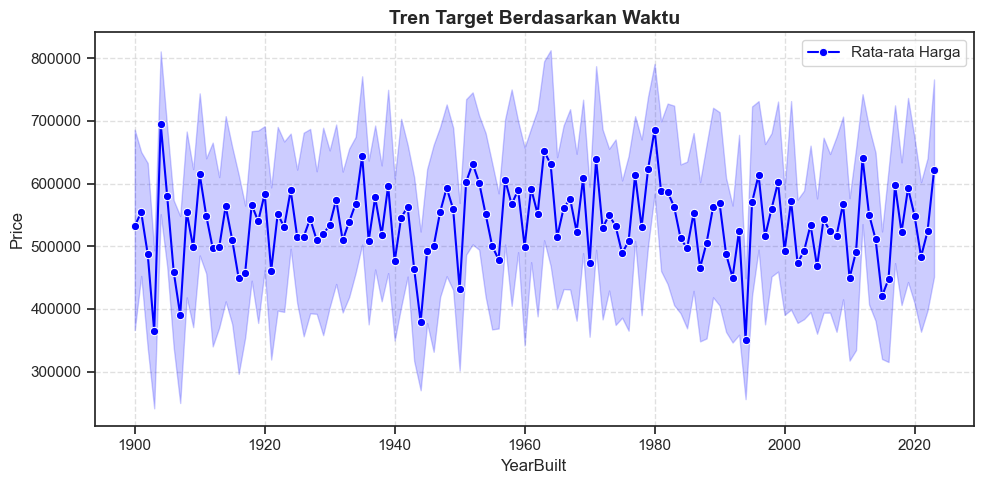

In [117]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x=feauture_time[0], y=feauture_target, color="blue", marker="o",label="Rata-rata Harga")
plt.title("Tren Target Berdasarkan Waktu", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 3.Analisis Bivariat

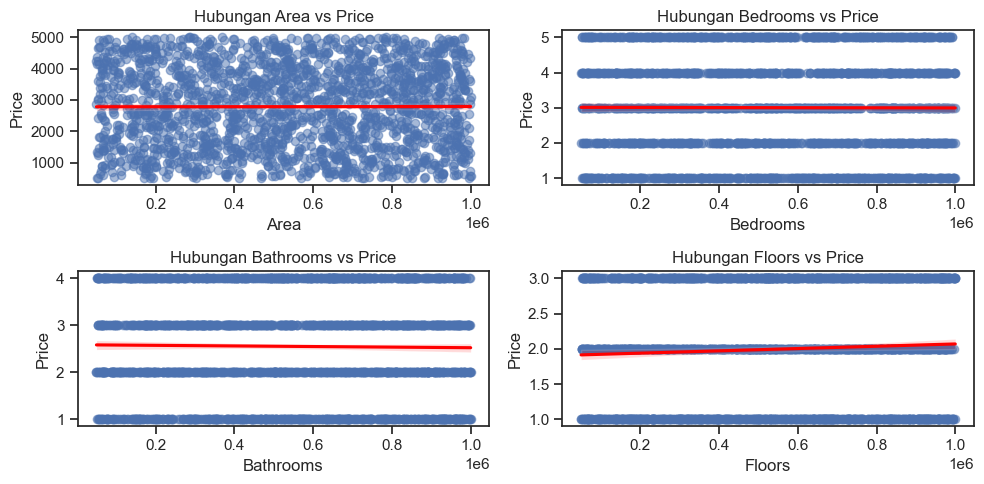

In [118]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.regplot(data=df, x=feauture_target, y=col, ax=axes[i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    axes[i].set_title(f"Hubungan {col} vs {feauture_target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(feauture_target)  # Hanya tampilkan label Y di grafik pertama

plt.tight_layout()
plt.show()

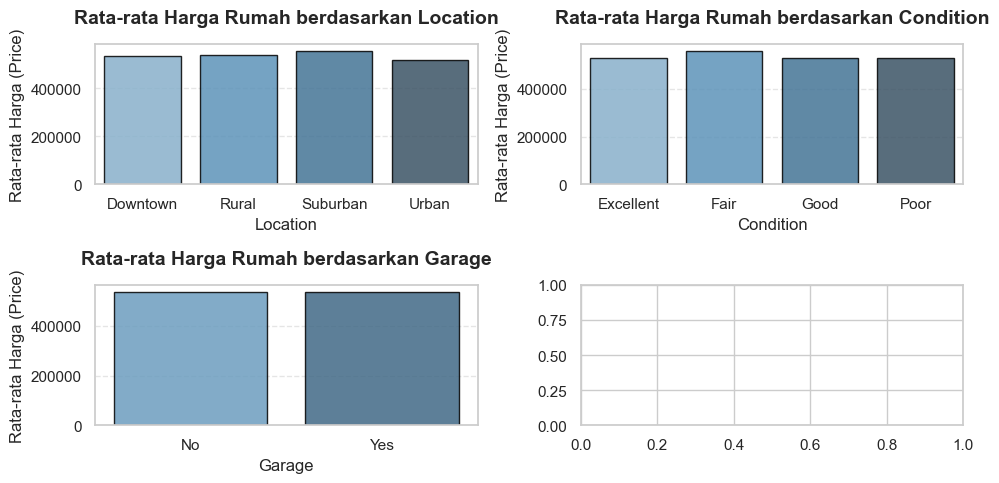

In [119]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10,5))
axes = axes.flatten()

for i, feature in enumerate(feauture_categori):
    mean_df = df.groupby(feature)[feauture_target].mean().reset_index()
    sns.barplot(data=mean_df, x=feature,  y=feauture_target, hue=feature, legend=False,ax=axes[i],palette="Blues_d",edgecolor="black",alpha=0.85)
    axes[i].set_title(f"Rata-rata Harga Rumah berdasarkan {feature}",fontsize=14,fontweight="bold",pad=15)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Rata-rata Harga (Price)", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

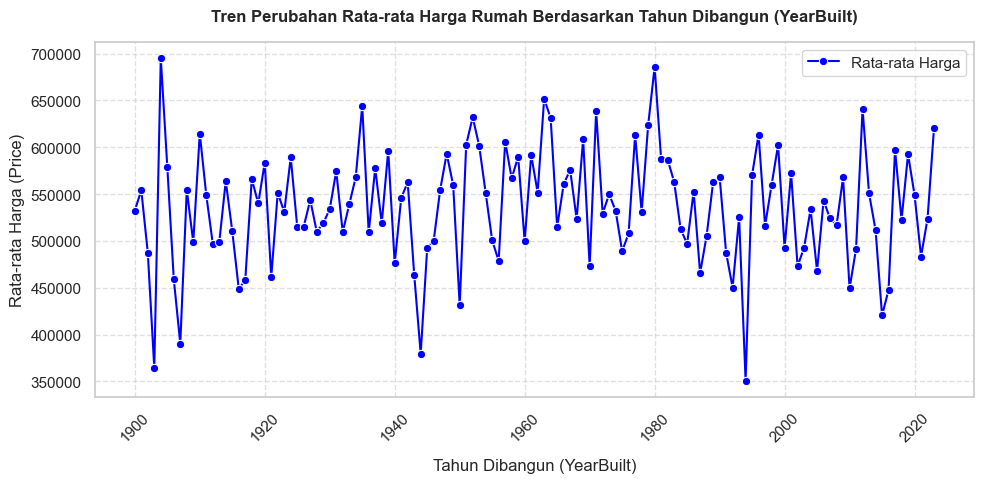

In [120]:
mean_df_year = df.groupby(feauture_time)[feauture_target].mean().reset_index()
plt.figure(figsize=(10, 5))


sns.lineplot(x=mean_df_year["YearBuilt"],y= mean_df_year["Price"], color="blue", marker="o",label="Rata-rata Harga")
plt.title("Tren Perubahan Rata-rata Harga Rumah Berdasarkan Tahun Dibangun (YearBuilt)",fontweight="bold",pad=15)
plt.xlabel("Tahun Dibangun (YearBuilt)", fontsize=12, labelpad=10)
plt.ylabel("Rata-rata Harga (Price)", fontsize=12)
plt.xticks(rotation=45)# Memiringkan angka tahun di sumbu X agar rapi jika rentang tahunnya panjang
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Analisis Multivariat

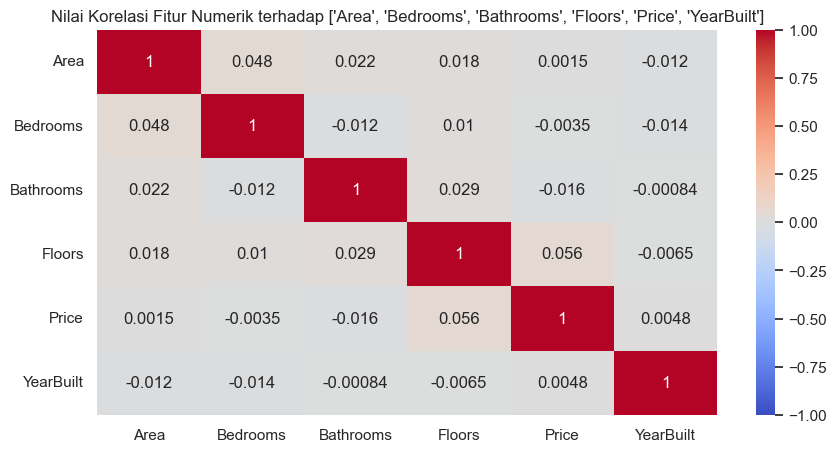

In [ ]:
plt.figure(figsize=(10, 5))
feature_corr = ['Area','Bedrooms','Bathrooms','Floors','Price','YearBuilt']
correlation_matrix = df[feature_corr].corr()

sns.heatmap(correlation_matrix[feature_corr],annot=True,cmap="coolwarm",vmin=-1,vmax=1,)
plt.title(f"Nilai Korelasi Fitur Numerik terhadap {feature_corr}")
plt.show()

## 6. Analisis Outliers

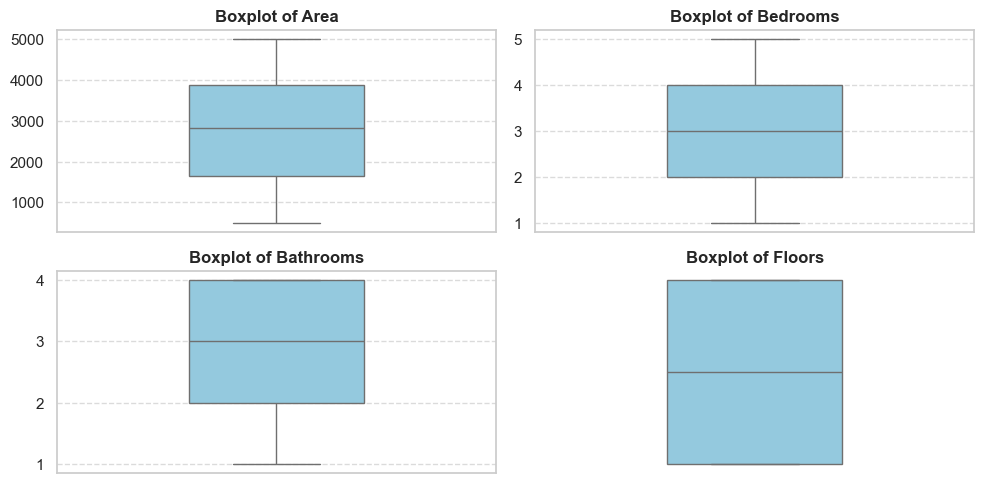

Jumlah outliers terdeteksi: 0


In [121]:
Q1 = df[feature_numerik].quantile(0.25)
Q3 = df[feature_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df.loc[((df[feature_numerik] < lower_bound) | (df[feature_numerik] > upper_bound)).any(axis=1)]

fig, axes = plt.subplots(2, 2 ,figsize=(10,5))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Mengosongkan label y agar lebih bersih
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

In [ ]:
file_path = "../0.dataset/dataset_House_Price_clean.csv"

if not path.exists(file_path):
    # Jika BELUM ADA, simpan data ke CSV
    df.to_csv(file_path, index=False)
    print("File belum ada. Berhasil menyimpan dataset baru!")
else:
    # Jika SUDAH ADA, lewati proses penyimpanan
    print("File sudah ada. Proses penyimpanan CSV dilewati (skip).")

df.head()

File sudah ada. Proses penyimpanan CSV dilewati (skip).


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056
